In [67]:
import geopandas as gpd
from pathlib import Path

# Define path do the data
data_folder = Path("data/_data/Austin")
fp = data_folder / "austin_pop_density_2019.gpkg"

# Read in the data and check the contents
data = gpd.read_file(fp)
data.head()

,pop2019,tract,area_km2,pop_density_km2,geometry
0,6070.0,002422,4.029772,1506.288778,"MULTIPOLYGON (((615643.488 3338728.496, 615645..."
1,2203.0,001751,1.532030,1437.961394,"MULTIPOLYGON (((618576.586 3359381.053, 618614..."
2,7419.0,002411,3.960344,1873.322161,"MULTIPOLYGON (((619200.163 3341784.654, 619270..."
3,4229.0,000401,2.181762,1938.341859,"MULTIPOLYGON (((621623.757 3350508.165, 621656..."
4,4589.0,002313,2.431208,1887.538658,"MULTIPOLYGON (((621630.247 3345130.744, 621717..."


In [68]:
data["geometry"].head()

0    MULTIPOLYGON (((615643.488 3338728.496, 615645...
1    MULTIPOLYGON (((618576.586 3359381.053, 618614...
2    MULTIPOLYGON (((619200.163 3341784.654, 619270...
3    MULTIPOLYGON (((621623.757 3350508.165, 621656...
4    MULTIPOLYGON (((621630.247 3345130.744, 621717...
Name: geometry, dtype: geometry

In [69]:
# Check data type of the geometry column
type(data["geometry"])

geopandas.geoseries.GeoSeries

In [70]:
# Check data type of a value in the geometry column
type(data["geometry"].values[0])

shapely.geometry.multipolygon.MultiPolygon

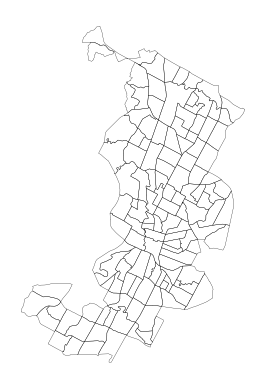

In [71]:
import matplotlib.pyplot as plt

data.plot(facecolor="none", linewidth=0.2)

plt.axis("off")
plt.show()

In [72]:
data.crs.name

'WGS 84 / UTM zone 14N'

In [73]:
data["geometry"].centroid.head()

0     POINT (616990.19 3339736.002)
1    POINT (619378.303 3359650.002)
2    POINT (620418.753 3342194.171)
3    POINT (622613.506 3351414.386)
4    POINT (622605.359 3343869.554)
dtype: geometry

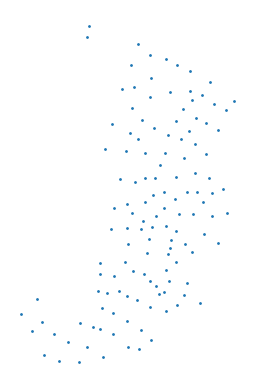

In [74]:
data.centroid.plot(markersize=1)

plt.axis("off")
plt.show()

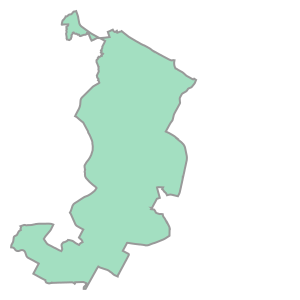

In [75]:
data.union_all()

In [76]:
# Merge geometries using coverage algorithm
dissolved = data.dissolve(method="coverage")
dissolved.head()

,geometry,pop2019,tract,area_km2,pop_density_km2
0,"MULTIPOLYGON (((618353.957 3340531.11, 618350....",6070.0,002422,4.029772,1506.288778


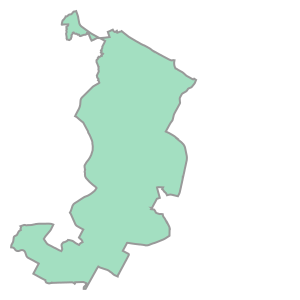

In [77]:
# Get the shapely geometry
dissolved.geometry[0]

In [78]:
data.envelope.head()

0    POLYGON ((615643.488 3337909.895, 618358.033 3...
1    POLYGON ((618529.497 3358797, 620192.632 33587...
2    POLYGON ((619198.456 3340875.421, 621733.88 33...
3    POLYGON ((621599.087 3350329.32, 623714.365 33...
4    POLYGON ((621630.247 3343015.679, 624133.189 3...
dtype: geometry

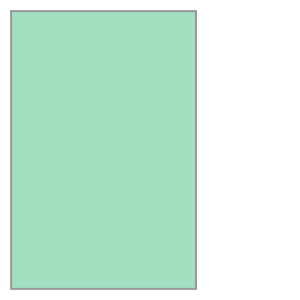

In [79]:
data.union_all().envelope

In [80]:
data.total_bounds

array([ 608125.39429998, 3337909.89499998,  629828.38850021,
       3370513.68260002])

In [81]:
data.bounds.head()

,minx,miny,maxx,maxy
0,615643.4875,3.337910e+06,618358.0327,3.341257e+06
1,618529.4971,3.358797e+06,620192.6319,3.360614e+06
2,619198.4560,3.340875e+06,621733.8796,3.343443e+06
3,621599.0866,3.350329e+06,623714.3655,3.352436e+06
4,621630.2470,3.343016e+06,624133.1887,3.345131e+06


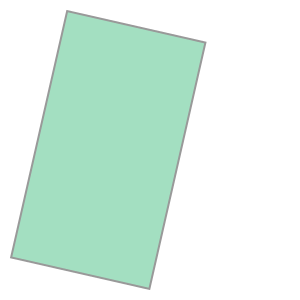

In [82]:
data.dissolve().minimum_rotated_rectangle().geometry[0]

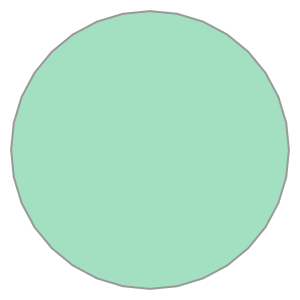

In [83]:
data.dissolve().minimum_bounding_circle().geometry[0]

In [84]:
data.convex_hull.head()

0    POLYGON ((616870.883 3337909.895, 616852.964 3...
1    POLYGON ((619496.705 3358797, 618962.703 33590...
2    POLYGON ((619848.5 3340875.421, 619811.394 334...
3    POLYGON ((622145.426 3350329.32, 622132.429 33...
4    POLYGON ((623931.77 3343015.679, 622426.307 33...
dtype: geometry

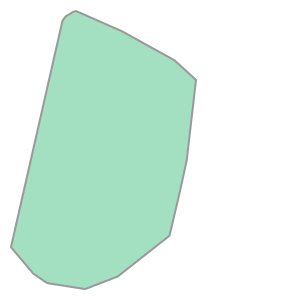

In [85]:
data.union_all().convex_hull

In [86]:
data.concave_hull().head()

0    POLYGON ((616686.447 3341251.083, 616689.559 3...
1    POLYGON ((619414.904 3360602.695, 619418.528 3...
2    POLYGON ((620165.029 3343417.634, 620177.845 3...
3    POLYGON ((622361.001 3352408.88, 622364.565 33...
4    POLYGON ((621654.405 3344983.596, 621630.247 3...
dtype: geometry

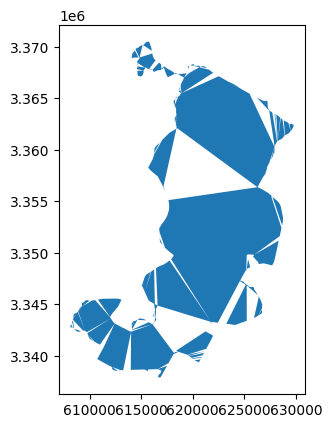

In [87]:
concave_hull = data.dissolve().concave_hull()
concave_hull.plot();

In [88]:
# Create GeoDataFrame of the union
gdf_union = data.dissolve()

# Ratio 0.05
concave_hull_a = gdf_union.concave_hull(ratio=0.05)

# Ratio 0.2
concave_hull_b = gdf_union.concave_hull(ratio=0.2)

# Ratio 0.4
concave_hull_c = gdf_union.concave_hull(ratio=0.4)

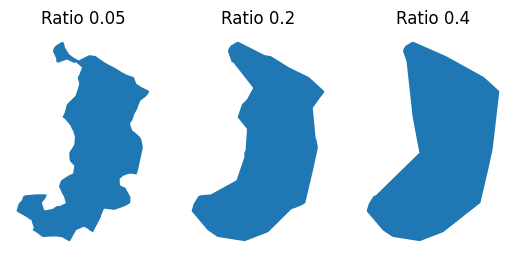

In [89]:
import matplotlib.pyplot as plt

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3)

# Plot side by side
concave_hull_a.plot(ax=ax1)
concave_hull_b.plot(ax=ax2)
concave_hull_c.plot(ax=ax3)

# Remove axis texts
ax1.axis("off")
ax2.axis("off")
ax3.axis("off")

# Add titles
ax1.set_title("Ratio 0.05")
ax2.set_title("Ratio 0.2")
ax3.set_title("Ratio 0.4");

In [90]:
data.simplify(tolerance=1000).head()

0    POLYGON ((615643.488 3338728.496, 616689.559 3...
1    POLYGON ((619496.705 3358797, 619418.528 33606...
2    POLYGON ((619200.163 3341784.654, 620177.845 3...
3    POLYGON ((621623.757 3350508.165, 622387.916 3...
4    POLYGON ((621630.247 3345130.744, 624133.189 3...
dtype: geometry

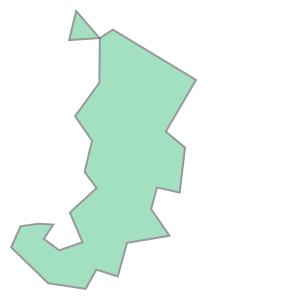

In [91]:
data.union_all().simplify(tolerance=1000)

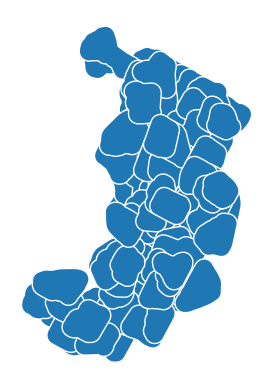

In [92]:
# 1000 m buffer for each polygon
data.buffer(1000).plot(edgecolor="white")

plt.axis("off")
plt.show()

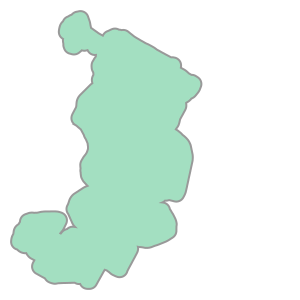

In [93]:
# 1000 m buffer for each polygon
data.union_all().buffer(1000)

In [94]:
# Create a new column and add a constant value
data["dense"] = 0

# Filter rows with above average pop density and update the column dense
data.loc[data["pop_density_km2"] > data["pop_density_km2"].mean(), "dense"] = 1

In [95]:
data.dense.value_counts()

dense
0    86
1    44
Name: count, dtype: int64

In [96]:
# Conduct the aggregation
dissolved = data[["pop2019", "area_km2", "dense", "geometry"]].dissolve(
    by="dense", aggfunc="sum"
)
dissolved

,geometry,pop2019,area_km2
dense,,,
0,"MULTIPOLYGON (((614108.23 3339640.551, 614288....",368992.0,231.131494
1,"MULTIPOLYGON (((612263.531 3338931.8, 612265.2...",242943.0,71.234570


In [97]:
dissolved = dissolved.reset_index()

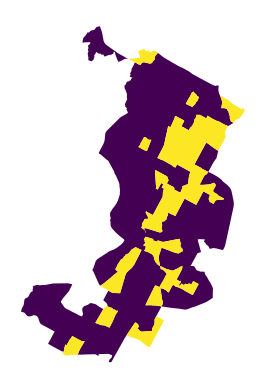

In [98]:
dissolved.plot(column="dense")

plt.axis("off")
plt.show()

# Exercise
### Create a 500m buffer zone around the dense areas in Austin and plot a simple map of this zone.

<Axes: >

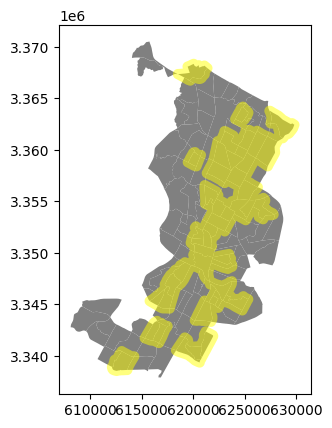

In [99]:
ax1 = data.plot(color="grey")
dissolved.loc[dissolved["dense"] == 1].buffer(500).plot(ax=ax1, alpha=0.5, color="yellow")

In [100]:
# Make a copy
option_1 = data.copy()
option_1["geometry"].head(2)

0    MULTIPOLYGON (((615643.488 3338728.496, 615645...
1    MULTIPOLYGON (((618576.586 3359381.053, 618614...
Name: geometry, dtype: geometry

In [101]:
# Update the geometry column with centroids
option_1["geometry"] = option_1.centroid
print(option_1.head(2))

   pop2019   tract  area_km2  pop_density_km2                        geometry  \
0   6070.0  002422  4.029772      1506.288778   POINT (616990.19 3339736.002)   
1   2203.0  001751  1.532030      1437.961394  POINT (619378.303 3359650.002)   

   dense  
0      0  
1      0  


In [102]:
# Make a copy and Create a column with centroids
option_2 = data.copy()
option_2["centroid"] = data.centroid
option_2.head(2)

,pop2019,tract,area_km2,pop_density_km2,geometry,dense,centroid
0,6070.0,002422,4.029772,1506.288778,"MULTIPOLYGON (((615643.488 3338728.496, 615645...",0,POINT (616990.19 3339736.002)
1,2203.0,001751,1.532030,1437.961394,"MULTIPOLYGON (((618576.586 3359381.053, 618614...",0,POINT (619378.303 3359650.002)


In [103]:
# Use centroids as the GeoDataFrame geometries
option2 = option_2.set_geometry("centroid")
option2.head(2)

,pop2019,tract,area_km2,pop_density_km2,geometry,dense,centroid
0,6070.0,002422,4.029772,1506.288778,"MULTIPOLYGON (((615643.488 3338728.496, 615645...",0,POINT (616990.19 3339736.002)
1,2203.0,001751,1.532030,1437.961394,"MULTIPOLYGON (((618576.586 3359381.053, 618614...",0,POINT (619378.303 3359650.002)


In [104]:
option2.geometry.name

'centroid'

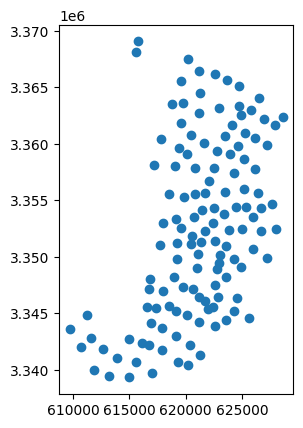

In [105]:
option2.plot();

In [108]:
import geopandas as gpd

# Read the file
fp = "data/_data/EU_countries/eu_countries_2022.gpkg"
data = gpd.read_file(fp)

# What is the type?
print(type(data.crs))

# Check the coordinate reference system information
data.crs

<class 'pyproj.crs.crs.CRS'>


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [109]:
data["geometry"].head()

0    MULTIPOLYGON (((13.684 46.4375, 13.511 46.3484...
1    MULTIPOLYGON (((6.3156 50.497, 6.405 50.3233, ...
2    MULTIPOLYGON (((28.498 43.4341, 28.0602 43.316...
3    MULTIPOLYGON (((16.9498 48.5358, 16.8511 48.43...
4    MULTIPOLYGON (((32.9417 34.6418, 32.559 34.687...
Name: geometry, dtype: geometry

In [110]:
# Let's make a backup copy of our data
data_wgs84 = data.copy()

# Reproject the data
data = data.to_crs(epsg=3035)

# Check the new geometry values
data["geometry"].head()

0    MULTIPOLYGON (((4604288.477 2598607.47, 459144...
1    MULTIPOLYGON (((4059689.242 3049361.18, 406508...
2    MULTIPOLYGON (((5805367.757 2442801.252, 57739...
3    MULTIPOLYGON (((4833567.363 2848881.974, 48272...
4    MULTIPOLYGON (((6413299.362 1602181.345, 63782...
Name: geometry, dtype: geometry

In [111]:
# Check the new EPSG code
data.crs.to_epsg()

3035

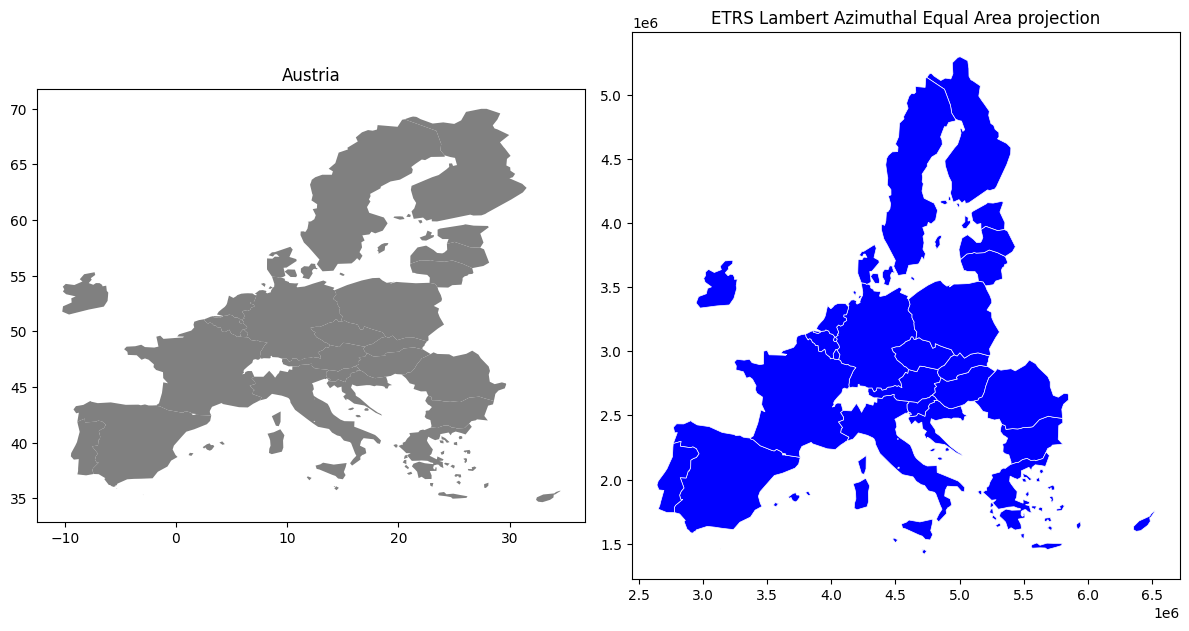

In [112]:
import matplotlib.pyplot as plt

# Make subplots that are next to each other
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 12))

# Plot the data in WGS84 CRS
data_wgs84.plot(ax=ax1, facecolor="gray")

# Plot the one with ETRS-LAEA projection
data.plot(ax=ax2, facecolor="blue", edgecolor="white", lw=0.5)

# Add titles
ax1.set_title("Austria")
ax2.set_title("ETRS Lambert Azimuthal Equal Area projection")

# Set aspect ratio as 1
ax1.set_aspect(aspect=1)
ax2.set_aspect(aspect=1)

# Remove empty white space around the plot
plt.tight_layout()

In [114]:
# Ouput filepath
outfp = "data/_data/EU_countries/Europe_borders_epsg3035.shp"

# Save to disk
data.to_file(outfp)

# Exercise

### Pick some CRS, e.g. ETRS89 / TM35FIN (EPSG:3067). And pick an EU country of your choice (e.g. Finland)

### First, select Finland from our dataset of EU countries; then, plot two maps of Finland where you compare the WGS84 (EPSG:4326) representation and ETRS89 / TM35FIN (EPSG:3067); you can achieve this by modifying the previous example for the whole EU.

In [126]:
data.head()

,CNTR_ID,CNTR_NAME,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,IT,Italia,Italy,Italie,ITA,UN Member State,Rome,T,F,F,Italien,"MULTIPOLYGON (((4604288.477 2598607.47, 459144..."
1,BE,Belgien-Belgique-België,Belgium,Belgique,BEL,UN Member State,Brussels,T,F,F,Belgien,"MULTIPOLYGON (((4059689.242 3049361.18, 406508..."
2,BG,България,Bulgaria,Bulgarie,BGR,UN Member State,Sofia,T,F,F,Bulgarien,"MULTIPOLYGON (((5805367.757 2442801.252, 57739..."
3,AT,Österreich,Austria,Autriche,AUT,UN Member State,Vienna,T,F,F,Österreich,"MULTIPOLYGON (((4833567.363 2848881.974, 48272..."
4,CY,Κύπρος-Kıbrıs,Cyprus,Chypre,CYP,UN Member State,Nicosia,T,F,F,Zypern,"MULTIPOLYGON (((6413299.362 1602181.345, 63782..."


In [159]:
finland_wgs84 = data_finland.loc[data_wgs84["NAME_ENGL"] == "Finland"].copy()
finland_etrs89 = finland_wgs84.to_crs(epsg=3067)

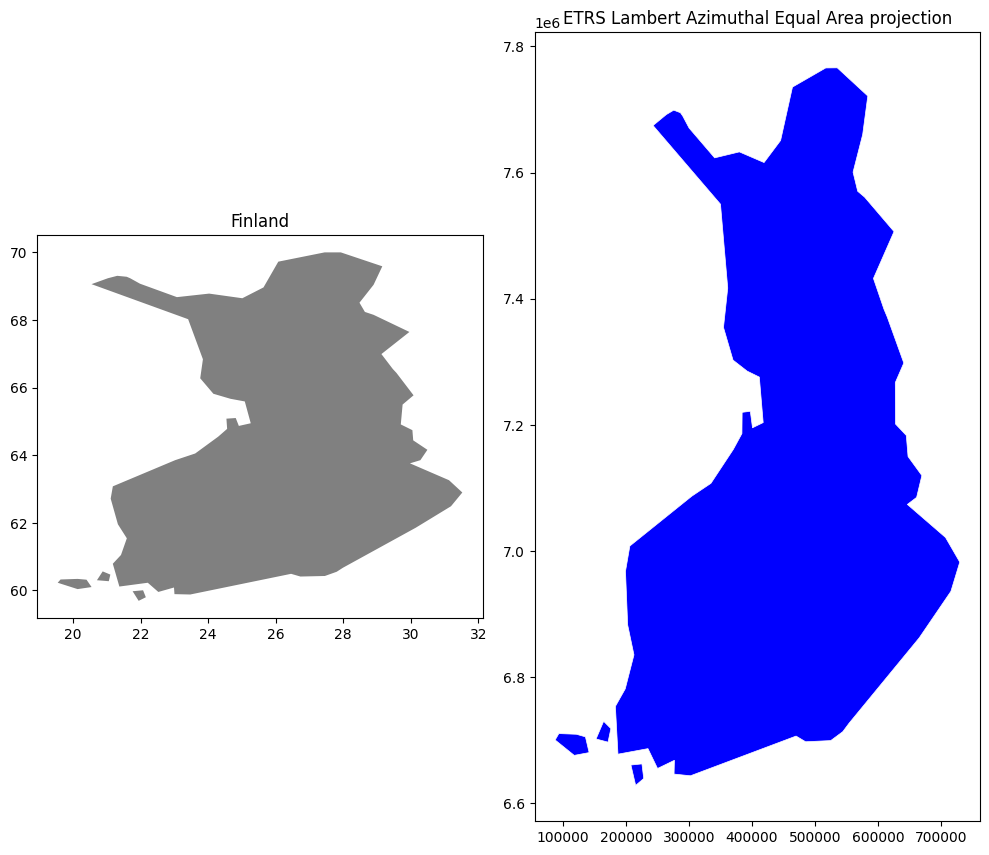

In [163]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))
# Plot the data in WGS84 CRS
finland_wgs84.plot(ax=ax1, facecolor="gray")

# Plot the one with ETRS-LAEA projection
finland_etrs89.plot(ax=ax2, facecolor="blue", edgecolor="white", lw=0.5)

# Add titles
ax1.set_title("Finland")
ax2.set_title("ETRS Lambert Azimuthal Equal Area projection")

# Set aspect ratio as 1
ax1.set_aspect(aspect=1)
ax2.set_aspect(aspect=1)

# Remove empty white space around the plot
plt.tight_layout()

In [164]:
from pyproj import CRS

crs_object = CRS.from_epsg(3035)

In [165]:
print("Name:", crs_object.name)
print("Coordinate system:", crs_object.coordinate_system)
print("Bounds:", crs_object.area_of_use.bounds)
print("Datum:", crs_object.datum)

Name: ETRS89-extended / LAEA Europe
Coordinate system: cartesian
Bounds: (-35.58, 24.6, 44.83, 84.73)
Datum: European Terrestrial Reference System 1989 ensemble


In [166]:
crs_wkt = crs_object.to_wkt()

In [167]:
# Retrieve EPSG code from WKT text
epsg = CRS(crs_wkt).to_epsg()
print(epsg)

3035


In [168]:
CRS(crs_wkt).to_epsg(min_confidence=25)

3035

In [169]:
from shapely.geometry import Point

# Create GeoDataFrame with one point
gdf = gpd.GeoDataFrame({"geometry": Point(24.950899, 60.169158)}, index=[0])
print(gdf.crs)

None


In [170]:
from pyproj import CRS

gdf = gdf.set_crs(CRS.from_epsg(4326))
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [172]:
import geopandas

fp = "data/_data/ne_110m_admin_0_countries.zip"
admin = gpd.read_file(fp)
admin.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

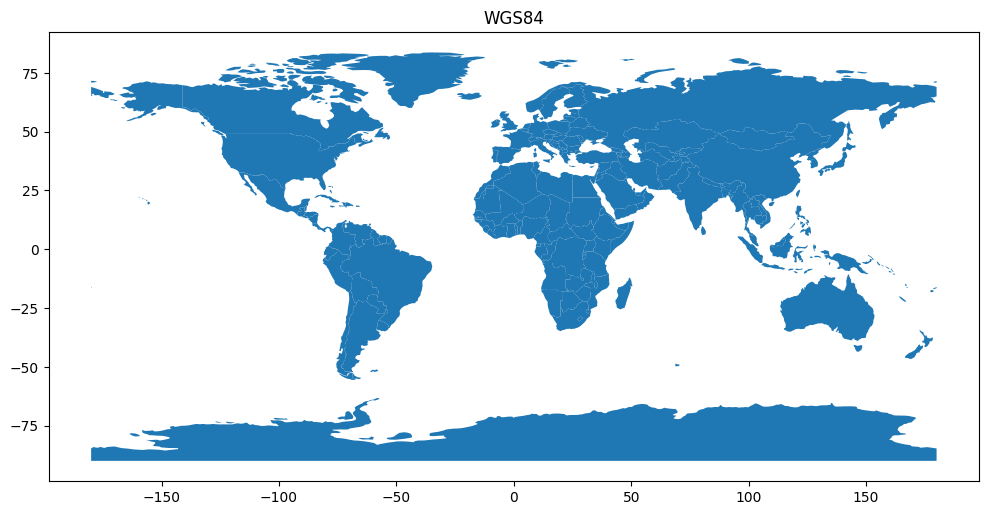

In [173]:
# Plot in original crs
admin.plot(figsize=(12, 6))
plt.title("WGS84");

In [174]:
admin.to_crs(epsg=3857).explore()

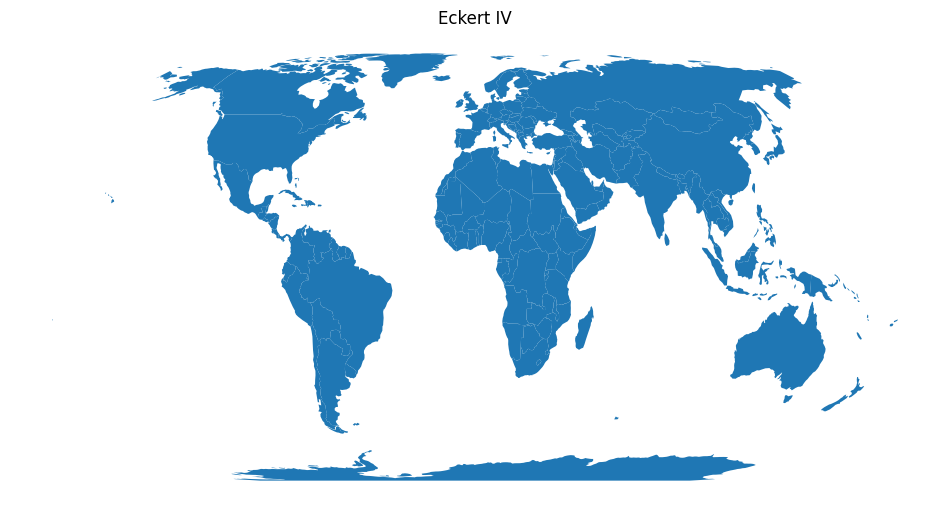

In [175]:
admin.to_crs(crs="ESRI:54012").plot(figsize=(12, 12))
plt.title("Eckert IV")
plt.axis("off");

C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\shapely\constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)
C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\shapely\constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)


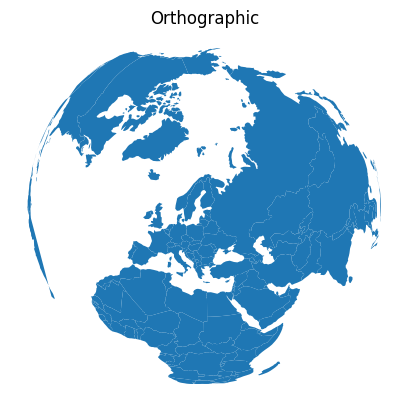

In [176]:
proj_string = "+proj=ortho +lat_0=60.00 +lon_0=24.0000"
admin.to_crs(crs=proj_string).plot()
plt.axis("off")
plt.title("Orthographic");

# Exercise

### Reproject the map around the place you were born in.

C:\Users\Andriy\analytics\labs\.venv\Lib\site-packages\shapely\constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)


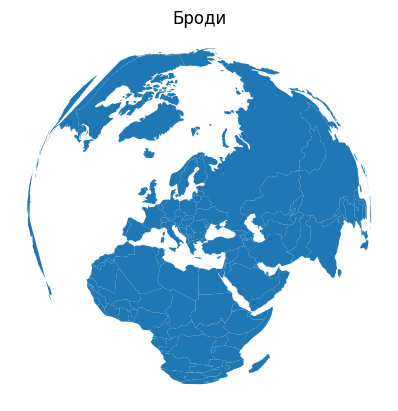

In [180]:
proj_string = "+proj=ortho +lat_0=50.078056 +lon_0=25.154167"
admin.to_crs(crs=proj_string).plot()
plt.axis("off")
plt.title("Броди");

In [181]:
# Import necessary modules
import pandas as pd
import geopandas as gpd

# Filepath
fp = "data/_data/Helsinki/addresses.txt"

# Read the data
data = pd.read_csv(fp, sep=";")
data.head()

,id,addr
0,1000,"Itämerenkatu 14, 00101 Helsinki, Finland"
1,1001,"Kampinkuja 1, 00100 Helsinki, Finland"
2,1002,"Kaivokatu 8, 00101 Helsinki, Finland"
3,1003,"Hermannin rantatie 1, 00580 Helsinki, Finland"
4,1005,"Tyynenmerenkatu 9, 00220 Helsinki, Finland"


In [182]:
from geopandas.tools import geocode

geo = geocode(
    data["addr"], provider="nominatim", user_agent="Adriana0157", timeout=10
)
geo.head()

,geometry,address
0,POINT (24.91556 60.1632),"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns..."
1,POINT (24.93166 60.16905),"Kamppi, 1, Kampinkuja, Kamppi, Eteläinen suurp..."
2,POINT (24.94146 60.17011),"Social Burgerjoint, 8, Kaivokatu, Keskusta, Kl..."
3,POINT (24.97687 60.18748),"Kalasatama, 1, Hermannin rantatie, Suvilahti, ..."
4,POINT (24.92151 60.15662),"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E..."


In [183]:
join = geo.join(data)
join.head()

,geometry,address,id,addr
0,POINT (24.91556 60.1632),"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns...",1000,"Itämerenkatu 14, 00101 Helsinki, Finland"
1,POINT (24.93166 60.16905),"Kamppi, 1, Kampinkuja, Kamppi, Eteläinen suurp...",1001,"Kampinkuja 1, 00100 Helsinki, Finland"
2,POINT (24.94146 60.17011),"Social Burgerjoint, 8, Kaivokatu, Keskusta, Kl...",1002,"Kaivokatu 8, 00101 Helsinki, Finland"
3,POINT (24.97687 60.18748),"Kalasatama, 1, Hermannin rantatie, Suvilahti, ...",1003,"Hermannin rantatie 1, 00580 Helsinki, Finland"
4,POINT (24.92151 60.15662),"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",1005,"Tyynenmerenkatu 9, 00220 Helsinki, Finland"


In [184]:
join.explore(color="red", marker_kwds={"radius": 5})

# Exercise
### Do another round of geocoding with your own list of addresses from anywhere in the world. Are you happy with the result?

### In the above example we passed the address column to the geocoding function. The geopandas documentation of geopandas.tools.geocode confirms that we should also be able to pass a list of strings to the geocoding tool. So, you should be able to answer this question by defining a list of addresses and using this list as input strings.

In [221]:

address_list = [
    "Grand Canyon National Park, Arizona, USA",
    "Great Barrier Reef, Queensland, Australia",
    "Guanabara Bay, Brazil",
    "Mount Qomolangma",
    "Kangerlussuaq",
    "Parícutin",
    "Victoria Falls"
]

In [227]:
from geopandas.tools import geocode
geog = geocode(address_list, provider="nominatim", user_agent="geo_wonders", timeout=10)
geog

,geometry,address
0,POINT (-112.2929 36.30785),"Grand Canyon National Park, Arizona, United St..."
1,POINT (148.95213 -20.35814),"Hamilton Island Airport, Airport Drive, Whitsu..."
2,POINT (-43.12722 -22.8169),"Baía de Guanabara, Região Metropolitana do Rio..."
3,POINT (86.92521 27.98806),"珠穆朗玛峰 ཇོ་མོ་གླང་མ། सगरमाथा, खुम्बु पासाङल्हामु..."
4,POINT (-50.69134 67.00868),"Kangerlussuaq, Qeqqata, Kalaallit Nunaat"
5,POINT (-102.25132 19.49317),"Parícutin, Uruapan, Michoacán, México"
6,POINT (25.85201 -17.92399),"Main Falls, Livingstone, Livingstone District,..."


# Сiм прирoдниx чудec cвiту зa вeрciєю *CNN*

In [228]:
geog.explore(color="red", marker_kwds={"radius": 5})

In [187]:
points = geo[["geometry"]].copy()
points.head()

,geometry
0,POINT (24.91556 60.1632)
1,POINT (24.93166 60.16905)
2,POINT (24.94146 60.17011)
3,POINT (24.97687 60.18748)
4,POINT (24.92151 60.15662)


In [189]:
from geopandas.tools import reverse_geocode

reverse_geocoded = reverse_geocode(
    points.geometry, provider="nominatim", user_agent="quarto_lnu", timeout=10
)
reverse_geocoded.head()

,geometry,address
0,POINT (24.91556 60.1632),"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns..."
1,POINT (24.93166 60.16905),"Kamppi, 1, Kampinkuja, Kamppi, Eteläinen suurp..."
2,POINT (24.94146 60.17011),"Social Burgerjoint, 8, Kaivokatu, Keskusta, Kl..."
3,POINT (24.97687 60.18748),"Kalasatama, 1, Hermannin rantatie, Suvilahti, ..."
4,POINT (24.92151 60.15662),"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E..."
